CML -- Coupled Map Lattice 
jisa paper have mentioned 1D CML, Although there 2D CML as well
See JISA paper for the equation No. 14-15

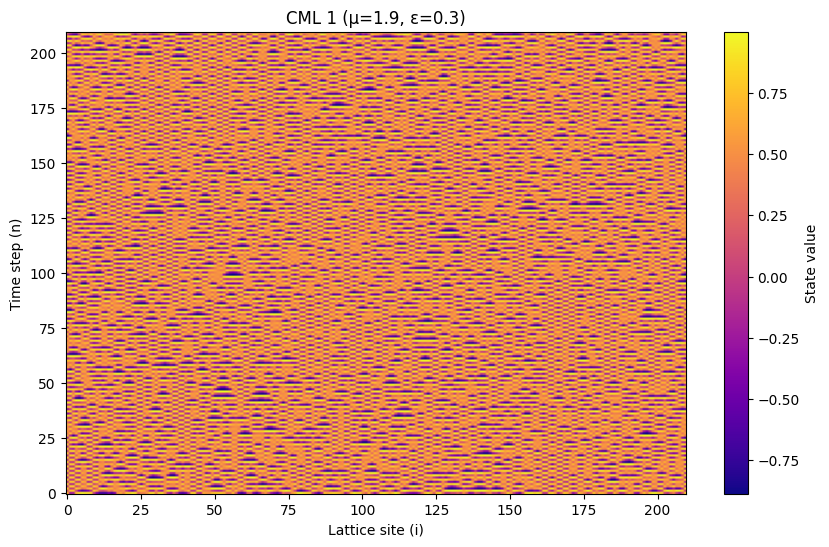

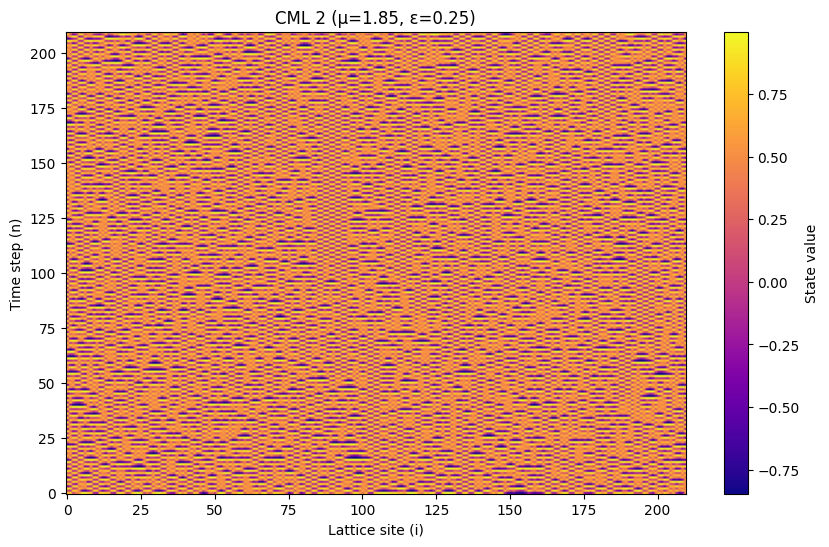

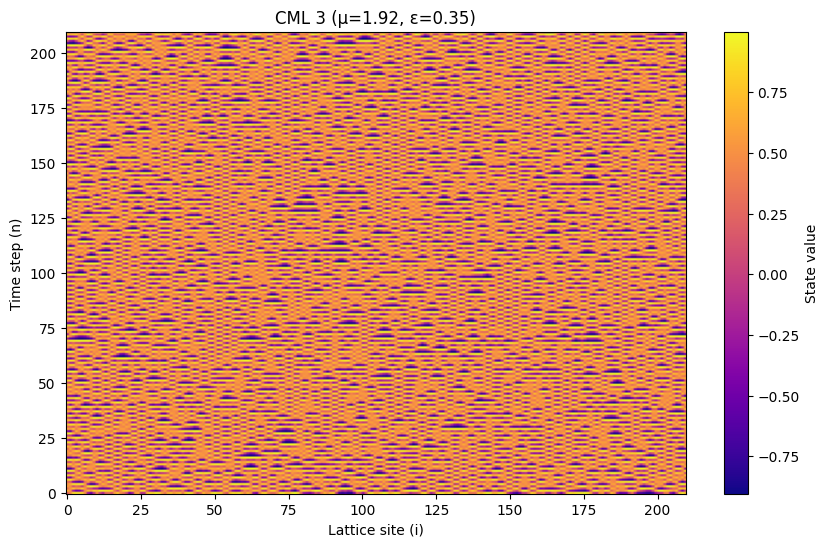

In [12]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt

Total_Image_Size = 44100
img_side = int(math.sqrt(Total_Image_Size))

# ---------------------------
# Logistic Map (for seeds)
# ---------------------------
def chaotic_function(x_n, r=3.9):
    return r * x_n * (1 - x_n)

# Generate chaotic sequence
my_values = []
r = 3.9
x_n = 0.5

for i in range(img_side * 3 + 10000):
    x_n = chaotic_function(x_n, r)
    if i >= 10000:  # burn initial transient
        my_values.append(x_n)

chaotic_df = pd.DataFrame({"value": my_values})

# ---------------------------
# Initial Conditions
# ---------------------------
x = chaotic_df['value'][0:img_side].values
y = chaotic_df['value'][img_side:2*img_side].values
z = chaotic_df['value'][2*img_side:3*img_side].values

# ---------------------------
# Parameters (DIFFERENT for each CML)
# ---------------------------
N = img_side
T = img_side
burn_in = 100  # required burn-in

mu1, eps1 = 1.9, 0.3
mu2, eps2 = 1.85, 0.25
mu3, eps3 = 1.92, 0.35

# ---------------------------
# CML function
# ---------------------------
def run_cml(initial_state, mu, eps):
    x = initial_state.copy()
    
    # Burn-in phase
    for _ in range(burn_in):
        fx = 1 - mu * (x ** 2)
        x_left = np.roll(fx, 1)
        x_right = np.roll(fx, -1)
        x = (1 - eps) * fx + (eps / 2) * (x_left + x_right)

    # Actual evolution storage
    cml = np.zeros((T, N))

    for t in range(T):
        cml[t] = x
        fx = 1 - mu * (x ** 2)
        x_left = np.roll(fx, 1)
        x_right = np.roll(fx, -1)
        x = (1 - eps) * fx + (eps / 2) * (x_left + x_right)

    return cml

# ---------------------------
# Run 3 independent CMLs
# ---------------------------
cml_1st = run_cml(x, mu1, eps1)
cml_2nd = run_cml(y, mu2, eps2)
cml_3rd = run_cml(z, mu3, eps3)

# ---------------------------
# Visualization
# ---------------------------
def plot_cml(cml, title):
    plt.figure(figsize=(10, 6))
    plt.imshow(cml, cmap="plasma", aspect="auto", origin="lower")
    plt.colorbar(label="State value")
    plt.xlabel("Lattice site (i)")
    plt.ylabel("Time step (n)")
    plt.title(title)
    plt.show()

plot_cml(cml_1st, "CML 1 (μ=1.9, ε=0.3)")
plot_cml(cml_2nd, "CML 2 (μ=1.85, ε=0.25)")
plot_cml(cml_3rd, "CML 3 (μ=1.92, ε=0.35)")

In [13]:
print(cml_1st.shape)
print(cml_2nd.shape)
print(cml_3rd.shape)
print(cml_1st)
print(cml_2nd)
print(cml_3rd)

(210, 210)
(210, 210)
(210, 210)
[[ 0.68236956 -0.23616964 -0.19851475 ... -0.2341195   0.11883809
   0.81839903]
 [ 0.17393185  0.78188244  0.77707584 ...  0.92301853  0.77470924
  -0.02753233]
 [ 0.78531648  0.00619935  0.021743   ... -0.55299862 -0.04125752
   0.81932021]
 ...
 [ 0.77675872  0.84168327  0.90875736 ...  0.56684142 -0.2315515
  -0.00995108]
 [-0.00439195 -0.34953317 -0.55604674 ...  0.34156193  0.83708925
   0.81263179]
 [ 0.77694935  0.74938526  0.45275127 ...  0.62841186 -0.15341045
  -0.0780029 ]]
[[ 0.71068339  0.80657652  0.12720562 ... -0.58900416 -0.4400847
   0.44695824]
 [ 0.10257365 -0.02319944  0.79680023 ...  0.4660962   0.60485275
   0.56123193]
 [ 0.91243774  0.85000171 -0.00863638 ...  0.47393836  0.36931001
   0.47592833]
 ...
 [ 0.21708397  0.64618088  0.93160387 ...  0.76486738  0.88067126
   0.45087981]
 [ 0.79104365  0.20905341 -0.45958506 ... -0.19072707 -0.25841761
   0.52768044]
 [ 0.05727462  0.74581267  0.69098894 ...  0.87836854  0.83454029
 

In [14]:
cml_1st_values=[]; cml_2nd_values=[];cml_3rd_values=[]; iterations=[]
for i in range(cml_1st.shape[0]):
    for j in range(cml_1st.shape[1]):
        iterations.append((i*img_side+j))
        cml_1st_values.append(cml_1st[i][j])
        cml_2nd_values.append(cml_2nd[i][j])
        cml_3rd_values.append(cml_3rd[i][j])
print(len(cml_1st_values))
print(len(cml_2nd_values))
print(len(cml_3rd_values))

cml_1st_values_df=pd.DataFrame()
cml_2nd_values_df=pd.DataFrame()
cml_3rd_values_df=pd.DataFrame()
cml_1st_values_df["iterations"]=iterations
cml_2nd_values_df["iterations"]=iterations
cml_3rd_values_df["iterations"]=iterations
cml_1st_values_df['values']=cml_1st_values
cml_2nd_values_df['values']=cml_2nd_values
cml_3rd_values_df['values']=cml_3rd_values
print(cml_1st_values_df)
print(cml_2nd_values_df)
print(cml_3rd_values_df)

44100
44100
44100
       iterations    values
0               0  0.682370
1               1 -0.236170
2               2 -0.198515
3               3  0.736552
4               4  0.859956
...           ...       ...
44095       44095  0.977338
44096       44096  0.888699
44097       44097  0.628412
44098       44098 -0.153410
44099       44099 -0.078003

[44100 rows x 2 columns]
       iterations    values
0               0  0.710683
1               1  0.806577
2               2  0.127206
3               3  0.362006
4               4  0.556450
...           ...       ...
44095       44095  0.758898
44096       44096  0.652348
44097       44097  0.878369
44098       44098  0.834540
44099       44099  0.453508

[44100 rows x 2 columns]
       iterations    values
0               0  0.211661
1               1  0.445904
2               2  0.853547
3               3  0.902605
4               4  0.875997
...           ...       ...
44095       44095  0.855357
44096       44096  0.285033
44097 